In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier
import re
import numpy as np
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix

In [2]:
#ruta donde se encuentra el dataset

In [3]:
ruta=

In [4]:
df = pd.read_csv(ruta+'procesos2016_2022_nuevas_var_disc_ipc.csv', sep='|',low_memory=False)
resultado = pd.read_csv(ruta+'resultado.csv', sep=',',low_memory=False)

df_propiedades_grafo = pd.read_csv(ruta+'proceso_propiedades_grafo.csv', sep=',',low_memory=False)

### Se construye el target

In [5]:
#construir la clase
#si el estado es Adjudicado, el proceso es exitoso, clase es 1
#si el estado es Desierto ó Dejado Sin Efecto, es no exitoso, clase es 0

df["targetB"] = (df["estado"] != "Adjudicado").astype(int)
# Crear el mapeo de estados a números
mapa_target = {
    "Adjudicado": 0,
    "Desierto": 1,
    "Dejado Sin Efecto": 2
}

# Crear la variable target usando map()
df["target"] = df["estado"].map(mapa_target)

### Se arman datasets con variables numéricas y categóricas separadas 

In [6]:
def limpiar_numero(x):
    if pd.isna(x):
        return np.nan
    x = str(x).lower().strip()
    if x in ["sin datos", "-", "", "nan"]:
        return np.nan   
    x = re.sub(r"[^\d.]", "", x)   # elimina letras y símbolos
    return pd.to_numeric(x, errors="coerce")

In [7]:
#se seleccionan las variables a utilizar del dataset
num_features=['cro_cant_dias_publicar','periodo_apertura','periodo_publicacion',
'periodo_inicio_consultas',
'periodo_final_consultas','periodo_inicio_recepcion_documentos','periodo_fin_recepcion_documentos','periodo_acto_apertura',
'dias_recepción_doc_soporte_fisico',
'duracion_contrato_dias','TOT_AGROPECUARIO','TOT_ALIMENTOS','TOT_ALQUILER',
'TOT_ART_HOGAR','TOT_BANCO','TOT_BAZAR','TOT_CARPINTERIA','TOT_CEREMONIAL','TOT_CERRAJERIA','TOT_CINE','TOT_COMBUSTIBLES','TOT_CONCESION','TOT_CONSTRUCCION',
'TOT_CULTURA','TOT_ELECTRICIDAD','TOT_LIMPIEZA','TOT_MUEBLES','TOT_EQUIPO_MILITAR','TOT_EQUIPOS','TOT_FERRETERIA','TOT_GASES_IND','TOT_HERRAMIENTAS',
'TOT_HERRERIA','TOT_IMPRENTA','TOT_INDUMENTARIA','TOT_INFORMATICA','TOT_INMUEBLES','TOT_INSUMO_ARMAMENTO','TOT_JOYERIA','TOT_LIBRERIA','TOT_MANTENIMIENTO','TOT_METALES','TOT_METALURGIA','TOT_NAUTICA','TOT_PINTURAS','TOT_PROD_MEDICOS','TOT_PROD_VETERINARIOS','TOT_QUIMICOS','TOT_REPUESTOS','TOT_PLOMERIA','TOT_SERV_PROFESIONAL',
'TOT_SERV_NOTICIAS','TOT_SERV_BASICOS','TOT_TAPICERIA','TOT_TRANSPORTE','TOT_PROD_DEPORTIVOS','TOT_VIDRIERIA','TOT_VIGILANCIA']

In [ ]:
df[num_features] = df[num_features].map(limpiar_numero)

In [9]:
cat_features = ['num_proceso','tipo_proceso','unidad_ejecutora','servicio_administrativo_financiero','modalidad','moneda','cotizacion','tipo_doc_compra', 
'requiere_pago','apartado', 'etapa_lic','etapa_autorizacion_pliego','etapa_autorizacion_llamado','etapa_acto_apertura','genera_recursos','financiamiento_externo',
'acepta_prorroga','cat_inicio_contrato','tipo_adquisicion']

### Se arman conjuntos de train y test

In [10]:
periodo_entrenamiento = 202112  # Último mes de entrenamiento
# Definir el periodo de prueba entre enero de 2020 (202001) y diciembre de 2022 (202212)
periodo_prueba_inicio = 202201  # Primer mes de prueba
periodo_prueba_fin = 202212    # Último mes de prueba

In [11]:
df_final = pd.concat([
    df[num_features],
    df[cat_features],
    df['target']
], axis=1)

In [12]:
#Convertir tus columnas a category
for col in cat_features:
    df_final[cat_features] = df_final[cat_features].astype("category")

In [13]:
# Filtrar los datos para entrenamiento (hasta diciembre de 2021)
df_train = df_final[df_final['periodo_apertura'] <= periodo_entrenamiento]

# Filtrar los datos para prueba (de enero de 2020 a diciembre de 2022)
df_test = df_final[(df_final['periodo_apertura'] >= periodo_prueba_inicio) & (df_final['periodo_apertura'] <= periodo_prueba_fin)]
# Verificar tamaños
print(f'Tamaño del conjunto de entrenamiento: {df_train.shape}')
print(f'Tamaño del conjunto de prueba: {df_test.shape}')

Tamaño del conjunto de entrenamiento: (55476, 78)
Tamaño del conjunto de prueba: (14210, 78)


In [14]:
y_train = df_train['target']
df_train=df_train.drop(columns=["target"])

y_test = df_test['target']
df_test=df_test.drop(columns=["target"])

In [15]:
class_counts = y_train.value_counts()
total = len(y_train)

# peso = total / (num_clases * frecuencia_clase)
class_weights = {}
for c, count in class_counts.items():
    weight = total / (len(class_counts) * count)

    # Multiplicar peso de clases 1 y 2 por 10
    if c in [1, 2]:
        weight *= 1.1

    class_weights[c] = weight

# Pasar los pesos a cada fila
sample_weights = y_train.map(class_weights)

class_weights


{0: 0.4299965120334845, 2: 1.82514131897712, 1: 15.34027149321267}

In [16]:
# 4 asegurar variables categóricas
for col in cat_features:
    df_train[col] = df_train[col].astype("category")
    df_test[col] = df_test[col].astype("category")

In [17]:
# 5 se define el modelo base
lgbm = LGBMClassifier(
    objective="multiclass",
    num_class=3,
    random_state=42,
    force_row_wise=True,
    verbosity=500
)

In [18]:
# 6 espacio de búsqueda
param_grid = {
    "n_estimators": [300, 600],
    "learning_rate": [0.03, 0.05],
    "max_depth": [5, 7],
    "num_leaves": [63, 127],
    "min_child_samples": [50, 100]
}

In [19]:
#7 métrica
f1_macro = make_scorer(f1_score, average="macro")

In [33]:
# 8 entrenar el modelo

grid_search = GridSearchCV(
    estimator=lgbm,
    param_grid=param_grid,
    scoring=f1_macro,
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(
    df_train,
    y_train,
    sample_weight=sample_weights
)

best_model = grid_search.best_estimator_

print("Mejor F1 macro:", grid_search.best_score_)
print("Mejores parámetros:")
print(grid_search.best_params_)

Fitting 3 folds for each of 32 candidates, totalling 96 fits
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.759844
[LightGBM] [Info] Total Bins 8053
[LightGBM] [Info] Number of data points in the train set: 55476, number of used features: 76
[LightGBM] [Info] Start training from score -1.163151
[LightGBM] [Info] Start training from score -1.067841
[LightGBM] [Info] Start training from score -1.067841
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Debug] Trained a tree with leaves = 25 and depth = 5
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Debug] Trained a tree with leaves = 31 and depth = 5
[LightGBM] [Warning] No further splits with positive gain, bes

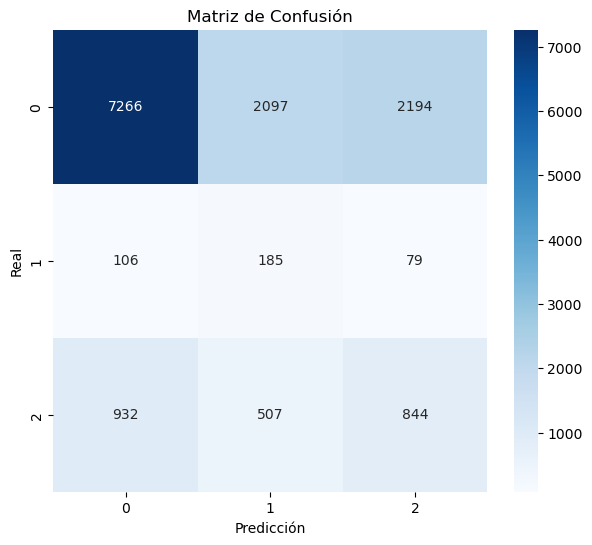

In [42]:
#14 se construye la matriz de confusión sobre el dataset de test
#y_pred = model.predict(df_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusión")
plt.ylabel("Real")
plt.xlabel("Predicción")
plt.show()

In [358]:

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.80      0.82     11557
           1       0.15      0.10      0.12       370
           2       0.27      0.37      0.31      2283

    accuracy                           0.71     14210
   macro avg       0.42      0.42      0.42     14210
weighted avg       0.74      0.71      0.72     14210



In [43]:
importance_split = pd.DataFrame({
    "feature": best_model.feature_name_,
    "importance_split": best_model.booster_.feature_importance(importance_type="split")
})

importance_split = importance_split.sort_values(
    "importance_split",
    ascending=False
)

print("\nTop 20 variables por SPLIT:")
print(importance_split.head(20))
importance_split.to_csv(ruta+'importancia_varLGBMM.csv')


Top 20 variables por SPLIT:
                                feature  importance_split
60                     unidad_ejecutora              4809
61   servicio_administrativo_financiero              1276
9                duracion_contrato_dias              1206
2                   periodo_publicacion               855
67                             apartado               810
8     dias_recepción_doc_soporte_fisico               809
1                      periodo_apertura               670
5   periodo_inicio_recepcion_documentos               588
4               periodo_final_consultas               508
76                     tipo_adquisicion               463
29                       TOT_FERRETERIA               407
48                        TOT_REPUESTOS               399
39                         TOT_LIBRERIA               381
6      periodo_fin_recepcion_documentos               379
40                    TOT_MANTENIMIENTO               315
50                 TOT_SERV_PROFESIONAL    

In [44]:


# -------------------------------------------------
# Predicción de probabilidades (3 clases)
# -------------------------------------------------
pred_prob = best_model.predict_proba(df_test)

# -------------------------------------------------
# Clase predicha (argmax)
# -------------------------------------------------
y_pred = np.argmax(pred_prob, axis=1)

# -------------------------------------------------
# Crear dataframe resultado
# -------------------------------------------------
resultado = resultado.copy()

resultado["LGBM_M_pred_class"] = y_pred
resultado["LGBM_M_prob_class_0"] = pred_prob[:, 0]
resultado["LGBM_M_prob_class_1"] = pred_prob[:, 1]
resultado["LGBM_M_prob_class_2"] = pred_prob[:, 2]

# -------------------------------------------------
# Validaciones rápidas 
# -------------------------------------------------
assert len(resultado) == len(df_test)
assert np.allclose(pred_prob.sum(axis=1), 1.0)

resultado.head()


,Unnamed: 0.1,Unnamed: 0,cro_cant_dias_publicar,periodo_apertura,periodo_publicacion,periodo_inicio_consultas,periodo_final_consultas,periodo_inicio_recepcion_documentos,periodo_fin_recepcion_documentos,periodo_acto_apertura,...,catB_pred_class,catB_prob_class_1,catB_prob_class_0,catBMG_pred_class,catBMG_prob_class_1,catBMG_prob_class_0,LGBM_M_pred_class,LGBM_M_prob_class_0,LGBM_M_prob_class_1,LGBM_M_prob_class_2
0,0,55476,0.0,202205,202204.0,202204.0,202205.0,NaN,NaN,202205.0,...,0,0.384456,0.615544,0,0.110035,0.889965,0,0.543100,0.007794,0.449106
1,1,55477,2.0,202205,202204.0,202204.0,202205.0,NaN,NaN,202205.0,...,0,0.387231,0.612769,0,0.092766,0.907234,0,0.570659,0.006030,0.423311
2,2,55478,0.0,202206,202205.0,202205.0,202206.0,NaN,NaN,202206.0,...,0,0.276112,0.723888,0,0.058406,0.941594,0,0.680698,0.002692,0.316610
3,3,55479,0.0,202204,202204.0,202204.0,202204.0,NaN,NaN,202204.0,...,0,0.486975,0.513025,0,0.045713,0.954287,2,0.377438,0.015553,0.607010
4,4,55480,0.0,202208,202208.0,202208.0,202208.0,NaN,NaN,202208.0,...,0,0.345004,0.654996,0,0.014977,0.985023,0,0.744793,0.018362,0.236845


In [45]:
resultado.to_csv(ruta+'resultado_LGMM.csv')

### Agregar las variables de métricas de grafo

In [49]:
df_train_metricas = df_train.merge(df_propiedades_grafo, on="num_proceso", how="left")
df_test_metricas = df_test.merge(df_propiedades_grafo, on="num_proceso", how="left")
df_test_metricas=df_test_metricas.drop('num_proceso',axis=1)
df_train_metricas=df_train_metricas.drop('num_proceso',axis=1)
cat_features=['tipo_proceso','unidad_ejecutora','servicio_administrativo_financiero','modalidad','moneda','cotizacion','tipo_doc_compra', 
'requiere_pago','apartado', 'etapa_lic','etapa_autorizacion_pliego','etapa_autorizacion_llamado','etapa_acto_apertura','genera_recursos','financiamiento_externo',
'acepta_prorroga','cat_inicio_contrato','tipo_adquisicion']

In [50]:
grid_search = GridSearchCV(
    estimator=lgbm,
    param_grid=param_grid,
    scoring=f1_macro,
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(
    df_train_metricas,
    y_train,
    sample_weight=sample_weights
)

best_model = grid_search.best_estimator_

print("Mejor F1 macro:", grid_search.best_score_)
print("Mejores parámetros:")
print(grid_search.best_params_)

Fitting 3 folds for each of 32 candidates, totalling 96 fits
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.692132
[LightGBM] [Info] Total Bins 9724
[LightGBM] [Info] Number of data points in the train set: 55476, number of used features: 82
[LightGBM] [Info] Start training from score -1.163151
[LightGBM] [Info] Start training from score -1.067841
[LightGBM] [Info] Start training from score -1.067841
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Debug] Trained a tree with leaves = 23 and depth = 5
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Debug] Trained a tree with leaves = 29 and depth = 5
[LightGBM] [Warning] No further splits with positive gain, bes

In [ ]:
best_model = random_search.best_estimator_

print("Mejor F1 macro:", random_search.best_score_)
print("Mejores parámetros:")
print(random_search.best_params_)

In [53]:
y_pred = best_model.predict(df_test_metricas)

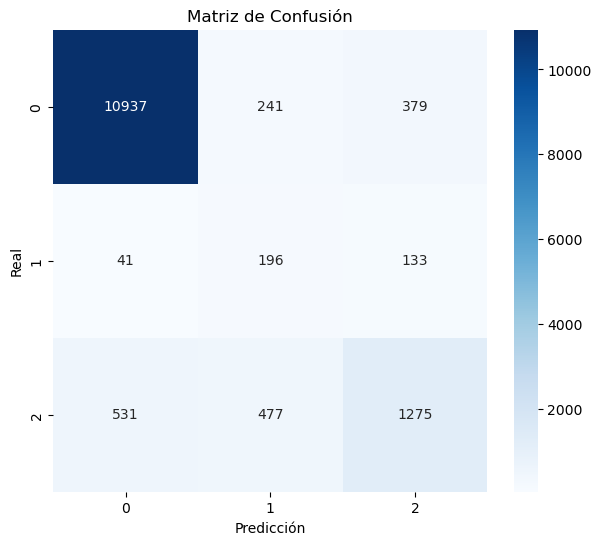

In [54]:
#se construye la matriz de confusión sobre el dataset de test
#y_pred = model.predict(df_test_metricas)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusión")
plt.ylabel("Real")
plt.xlabel("Predicción")
plt.show()

In [55]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95     11557
           1       0.21      0.53      0.31       370
           2       0.71      0.56      0.63      2283

    accuracy                           0.87     14210
   macro avg       0.63      0.68      0.63     14210
weighted avg       0.89      0.87      0.88     14210



In [56]:
importance_split = pd.DataFrame({
    "feature": best_model.feature_name_,
    "importance_split": best_model.booster_.feature_importance(importance_type="split")
})

importance_split = importance_split.sort_values(
    "importance_split",
    ascending=False
)

print("\nTop 20 variables por SPLIT:")
print(importance_split.head(20))
importance_split.to_csv(ruta+'importancia_varLGBM_MG.csv')


Top 20 variables por SPLIT:
                               feature  importance_split
59                    unidad_ejecutora              4646
81                          p.pagerank              2178
79                             p.grado              1241
77                            p.cosine              1098
76                       p.betweenness               994
78                  p.eigen_centrality               765
60  servicio_administrativo_financiero               747
75                    tipo_adquisicion               654
66                            apartado               557
82                   p.vecinos_comunes               541
50                TOT_SERV_PROFESIONAL               419
9               duracion_contrato_dias               419
2                  periodo_publicacion               408
8    dias_recepción_doc_soporte_fisico               399
1                     periodo_apertura               322
61                           modalidad               291
28

In [57]:

# -------------------------------------------------
# Predicción de probabilidades (3 clases)
# -------------------------------------------------
#pred_prob = best_model.predict_proba(df_test)

# -------------------------------------------------
# Clase predicha (argmax)
# -------------------------------------------------
y_pred = np.argmax(pred_prob, axis=1)

# -------------------------------------------------
# Crear dataframe resultado
# -------------------------------------------------
resultado = resultado.copy()

resultado["LGBM_MMG_pred_class"] = y_pred
resultado["LGBM_MMG_prob_class_0"] = pred_prob[:, 0]
resultado["LGBM_MMG_prob_class_1"] = pred_prob[:, 1]
resultado["LGBM_MMG_prob_class_2"] = pred_prob[:, 2]

# -------------------------------------------------
# Validaciones rápidas 
# -------------------------------------------------
assert len(resultado) == len(df_test)
assert np.allclose(pred_prob.sum(axis=1), 1.0)

resultado.head()

,Unnamed: 0.1,Unnamed: 0,cro_cant_dias_publicar,periodo_apertura,periodo_publicacion,periodo_inicio_consultas,periodo_final_consultas,periodo_inicio_recepcion_documentos,periodo_fin_recepcion_documentos,periodo_acto_apertura,...,catBMG_prob_class_1,catBMG_prob_class_0,LGBM_M_pred_class,LGBM_M_prob_class_0,LGBM_M_prob_class_1,LGBM_M_prob_class_2,LGBM_MMG_pred_class,LGBM_MMG_prob_class_0,LGBM_MMG_prob_class_1,LGBM_MMG_prob_class_2
0,0,55476,0.0,202205,202204.0,202204.0,202205.0,NaN,NaN,202205.0,...,0.110035,0.889965,0,0.543100,0.007794,0.449106,0,0.543100,0.007794,0.449106
1,1,55477,2.0,202205,202204.0,202204.0,202205.0,NaN,NaN,202205.0,...,0.092766,0.907234,0,0.570659,0.006030,0.423311,0,0.570659,0.006030,0.423311
2,2,55478,0.0,202206,202205.0,202205.0,202206.0,NaN,NaN,202206.0,...,0.058406,0.941594,0,0.680698,0.002692,0.316610,0,0.680698,0.002692,0.316610
3,3,55479,0.0,202204,202204.0,202204.0,202204.0,NaN,NaN,202204.0,...,0.045713,0.954287,2,0.377438,0.015553,0.607010,2,0.377438,0.015553,0.607010
4,4,55480,0.0,202208,202208.0,202208.0,202208.0,NaN,NaN,202208.0,...,0.014977,0.985023,0,0.744793,0.018362,0.236845,0,0.744793,0.018362,0.236845


In [58]:
resultado.to_csv(ruta+'resulatdo_lgbm.csv')

### Target Binario

In [421]:
y_train= y_train.replace({2: 1})
y_test= y_test.replace({2: 1})

In [422]:
weights = compute_class_weight(
    class_weight="balanced",
    classes=[0, 1],
    y=y_train
)

# reforzar clase positiva
weights[1] *= 1.1

class_weight = {0: weights[0], 1: weights[1]}
class_weight

{0: 0.6449947680502267, 1: 2.4466201587683427}

In [423]:
for col in cat_features:
    df_train[col] = df_train[col].astype("category")
    df_test[col] = df_test[col].astype("category")


In [424]:
lgbm = LGBMClassifier(
    objective="binary",
    random_state=42,
    force_row_wise=True,
    verbosity=50,
    class_weight=class_weight
)

In [425]:
param_dist = {
    "n_estimators": [200, 400, 600],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [5, 7, -1],
    "num_leaves": [63, 127],
    "min_child_samples": [50, 100],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "max_bin": [255, 512]
}

In [426]:
f1_binary = make_scorer(f1_score)

In [427]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_dist,
    n_iter=30,
    scoring=f1_binary,
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_search.fit(df_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 12471, number of negative: 43005
[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.759844
[LightGBM] [Info] Total Bins 8053
[LightGBM] [Info] Number of data points in the train set: 55476, number of used features: 76
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.523810 -> initscore=0.095310
[LightGBM] [Info] Start training from score 0.095310
[LightGBM] [Debug] Trained a tree with leaves = 127 and depth = 19
[LightGBM] [Debug] Trained a tree with leaves = 127 and depth = 21
[LightGBM] [Debug] Trained a tree with leaves = 127 and depth = 17
[LightGBM] [Debug] Trained a tree with leaves = 127 and depth = 18
[LightGBM] [Debug] Trained a tre

RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=LGBMClassifier(class_weight={0: 0.6449947680502267,
                                                          1: 2.4466201587683427},
                                            force_row_wise=True,
                                            objective='binary', random_state=42,
                                            verbosity=50),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_bin': [255, 512],
                                        'max_depth': [5, 7, -1],
                                        'min_child_samples': [50, 100],
                                        'n_estimators': [200, 400, 600],
                                        'num_leaves': [63, 127],
                                        'subsample': [0.8, 1.0]},
                   random_state=42, scoring=make_scorer(f1_score), verbose=2)

In [428]:
best_model = random_search.best_estimator_

print("Mejor F1:", random_search.best_score_)
print("Mejores parámetros:")
print(random_search.best_params_)

Mejor F1: 0.4591345661916618
Mejores parámetros:
{'subsample': 1.0, 'num_leaves': 127, 'n_estimators': 400, 'min_child_samples': 100, 'max_depth': -1, 'max_bin': 255, 'learning_rate': 0.01, 'colsample_bytree': 0.8}


In [429]:
#7 métrica
f1_macro = make_scorer(f1_score, average="macro")

In [430]:
#12 mejor modelo
best_model = random_search.best_estimator_

print("Mejor F1 macro:", random_search.best_score_)
print("Mejores parámetros:")
print(random_search.best_params_)

Mejor F1 macro: 0.4591345661916618
Mejores parámetros:
{'subsample': 1.0, 'num_leaves': 127, 'n_estimators': 400, 'min_child_samples': 100, 'max_depth': -1, 'max_bin': 255, 'learning_rate': 0.01, 'colsample_bytree': 0.8}


In [431]:
#13 evaluar en test
y_pred = best_model.predict(df_test)

print(
    classification_report(
        y_test,
        y_pred,
        digits=3
    )
)

cm = confusion_matrix(y_test, y_pred)

              precision    recall  f1-score   support

           0      0.871     0.745     0.803     11557
           1      0.318     0.518     0.394      2653

    accuracy                          0.703     14210
   macro avg      0.594     0.632     0.599     14210
weighted avg      0.768     0.703     0.727     14210



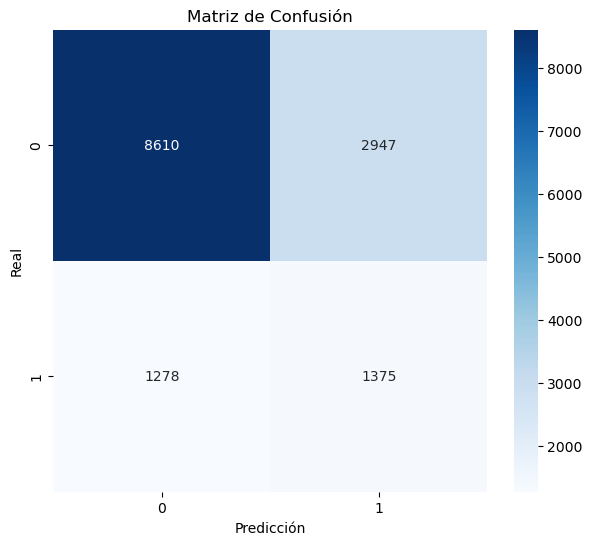

In [432]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusión")
plt.ylabel("Real")
plt.xlabel("Predicción")
plt.show()

In [433]:
importance_split = pd.DataFrame({
    "feature": best_model.feature_name_,
    "importance_split": best_model.booster_.feature_importance(importance_type="split")
})

importance_split = importance_split.sort_values(
    "importance_split",
    ascending=False
)

print("\nTop 20 variables por SPLIT:")
print(importance_split.head(20))
importance_split.to_csv(ruta+'importancia_varLGBM_Binario.csv')


Top 20 variables por SPLIT:
                                feature  importance_split
60                     unidad_ejecutora              9954
61   servicio_administrativo_financiero              3507
9                duracion_contrato_dias              3090
2                   periodo_publicacion              2431
1                      periodo_apertura              2260
8     dias_recepción_doc_soporte_fisico              1909
4               periodo_final_consultas              1757
5   periodo_inicio_recepcion_documentos              1701
48                        TOT_REPUESTOS              1491
6      periodo_fin_recepcion_documentos              1331
67                             apartado              1250
3              periodo_inicio_consultas              1223
40                    TOT_MANTENIMIENTO              1188
75                  cat_inicio_contrato              1125
50                 TOT_SERV_PROFESIONAL              1087
29                       TOT_FERRETERIA    

In [434]:

# -------------------------------------------------
# Predicción de probabilidades (binario)
# -------------------------------------------------
pred_prob = best_model.predict_proba(df_test)

# -------------------------------------------------
# Clase predicha (threshold 0.5)
# -------------------------------------------------
y_pred = (pred_prob[:, 1] >= 0.5).astype(int)

# -------------------------------------------------
# Crear dataframe resultado
# -------------------------------------------------
resultado = resultado.copy()

resultado["LGBM_B_pred_class"] = y_pred
resultado["LGBM_B_prob_class_0"] = pred_prob[:, 0]
resultado["LGBM_B_prob_class_1"] = pred_prob[:, 1]

# -------------------------------------------------
# Validaciones rápidas (opcional)
# -------------------------------------------------
assert len(resultado) == len(df_test)
assert np.allclose(pred_prob.sum(axis=1), 1.0)

resultado

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,cro_cant_dias_publicar,periodo_apertura,periodo_publicacion,periodo_inicio_consultas,periodo_final_consultas,periodo_inicio_recepcion_documentos,periodo_fin_recepcion_documentos,...,xgbM_prob_class_0,xgbM_prob_class_1,xgbM_prob_class_2,LGBM_MMG_pred_class,LGBM_MMG_prob_class_0,LGBM_MMG_prob_class_1,LGBM_MMG_prob_class_2,LGBM_B_pred_class,LGBM_B_prob_class_0,LGBM_B_prob_class_1
0,0,0,55476,0.0,202205,202204.0,202204.0,202205.0,NaN,NaN,...,0.661801,0.000899,0.337300,0,0.721414,0.000816,0.277769,0,0.763140,0.236860
1,1,1,55477,2.0,202205,202204.0,202204.0,202205.0,NaN,NaN,...,0.671881,0.000773,0.327347,0,0.829541,0.000373,0.170087,0,0.777975,0.222025
2,2,2,55478,0.0,202206,202205.0,202205.0,202206.0,NaN,NaN,...,0.722303,0.000831,0.276866,0,0.908239,0.000048,0.091713,0,0.805708,0.194292
3,3,3,55479,0.0,202204,202204.0,202204.0,202204.0,NaN,NaN,...,0.569888,0.000945,0.429167,0,0.513717,0.005117,0.481166,0,0.532052,0.467948
4,4,4,55480,0.0,202208,202208.0,202208.0,202208.0,NaN,NaN,...,0.335176,0.002309,0.662515,0,0.877954,0.006212,0.115834,0,0.753808,0.246192
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14205,14205,14205,69681,0.0,202201,202201.0,202201.0,202201.0,NaN,NaN,...,0.522875,0.208563,0.268562,1,0.270343,0.651727,0.077930,0,0.599677,0.400323
14206,14206,14206,69682,0.0,202206,202206.0,202206.0,202206.0,NaN,NaN,...,0.745114,0.008120,0.246766,0,0.750422,0.014638,0.234940,0,0.631338,0.368662
14207,14207,14207,69683,0.0,202211,202211.0,202211.0,202211.0,NaN,NaN,...,0.563036,0.016004,0.420961,0,0.565670,0.153997,0.280333,0,0.515455,0.484545
14208,14208,14208,69684,0.0,202205,202205.0,202205.0,202205.0,NaN,NaN,...,0.740915,0.128663,0.130422,0,0.777632,0.165935,0.056433,0,0.671040,0.328960


In [435]:
resultado.to_csv(ruta+'resultado_lightGBM.csv')